In [1]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
output_path = '/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr/test_fixed_cgmvae_1000epochs'
epoch = 1000
dataset_abbrev =  ['HC', 'PFC']

In [3]:
input_data = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv')
input_data

/tmp/ipykernel_777057/298928447.py:1: DtypeWarning: Columns (9712) have mixed types. Specify dtype option on import or set low_memory=False.
  input_data = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv')


,0_HC,1_HC,2_HC,3_HC,4_HC,5_HC,6_HC,7_HC,8_HC,9_HC,...,subclass_PFC,cell_type_PFC,SCBID_PFC,MouseID_PFC,Age_PFC,Genotype_PFC,CFM_14_5_snRNA_PFC,14-6-residual_PFC,14-6-Bin_PFC,strain
0,1.032911,0.930804,-0.506429,0.399180,-1.665557,-0.169929,-0.412642,-1.081330,-0.263578,-1.602702,...,334 Microglia NN,Immune,CK19032,1596,14,5,59.16,0.738297,3,124
1,0.652837,0.454148,0.879128,0.030314,-1.489111,0.785163,0.211441,0.474034,-0.107822,-0.063107,...,319 Astro-TE NN,Astrocytes,CK19032,1596,14,5,59.16,0.738297,3,124
2,-0.467760,0.498727,0.423371,-0.196953,-0.577146,-0.254714,0.647625,0.110877,-0.037445,-0.114378,...,030 L6 CT CTX Glut,Glut,CK19032,1596,14,5,59.16,0.738297,3,124
3,0.269693,0.008788,0.001615,0.248190,0.531861,0.174182,-0.656014,0.324071,-0.270391,-0.172469,...,007 L2/3 IT CTX Glut,Glut,CK19032,1596,14,5,59.16,0.738297,3,124
4,0.474351,2.694790,-2.235378,1.500846,-0.067623,0.446731,0.536872,0.355713,-0.701760,-0.677066,...,327 Oligo NN,Oligo,CK19032,1596,14,5,59.16,0.738297,3,124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-0.749929,-0.952024,0.792208,0.094389,2.632507,-1.873176,0.380587,-3.843666,0.418903,0.134437,...,334 Microglia NN,Immune,CK19090,1490,14,5,39.47,-0.460462,1,28
9747,-0.521517,-1.567496,0.704327,-0.186926,1.173094,-0.662684,-0.474026,0.286059,1.187299,1.694772,...,066 NDB-SI-ant Prdm12 Gaba,Gaba,CK19090,1490,14,5,39.47,-0.460462,1,28
9748,0.030754,-1.881689,-0.582833,2.284414,0.035602,1.502603,1.283200,0.003121,1.818799,0.914294,...,327 Oligo NN,Oligo,CK19090,1490,14,5,39.47,-0.460462,1,28
9749,-0.178791,-0.578603,0.148001,-0.718415,-0.050875,0.533299,1.350025,-1.728900,-1.629589,0.284877,...,010 IT AON-TT-DP Glut,Glut,CK19090,1490,14,5,39.47,-0.460462,1,28


In [4]:
np.max(input_data.iloc[:, :4842]), np.min(input_data.iloc[:, :4842]), np.std(input_data.iloc[:, :4842]).mean(), np.mean(input_data.iloc[:, :4842])

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


(10.73692086318994,
 -11.08106806840177,
 0.9976367561093517,
 0.00022066111286812607)

In [5]:
np.max(input_data.iloc[:, 4842+10:-11]), np.min(input_data.iloc[:, 4842+10:-11]), np.std(input_data.iloc[:, 4842+10:-11]).mean(), np.mean(input_data.iloc[:, 4842+10:-11])

(15.672249011449566,
 -13.73006357983693,
 1.0063573224030393,
 -9.378702617765428e-05)

In [6]:
PFC_from_HC = pd.read_csv(os.path.join(output_path, f'recon{dataset_abbrev[1]}_epoch{epoch}_vae{dataset_abbrev[0]}.csv'))
PFC_from_HC

/tmp/ipykernel_777057/1571815331.py:1: DtypeWarning: Columns (4860) have mixed types. Specify dtype option on import or set low_memory=False.
  PFC_from_HC = pd.read_csv(os.path.join(output_path, f'recon{dataset_abbrev[1]}_epoch{epoch}_vae{dataset_abbrev[0]}.csv'))


,0,1,2,3,4,5,6,7,8,9,...,barcode_PFC,subclass_PFC,cell_type_PFC,SCBID_PFC,MouseID_PFC,Age_PFC,Genotype_PFC,14-6-residual_PFC,14-6-Bin_PFC,strain
0,0.154988,0.137181,0.158549,0.171073,0.138296,0.153876,0.131109,0.176736,0.135001,0.169701,...,CK19032_AATCACGGTTCAGTAC-1,334 Microglia NN,Immune,CK19032,1596,14,5,0.738297,3,124
1,0.142954,0.137834,0.147395,0.177874,0.168916,0.143474,0.171384,0.178672,0.116269,0.201101,...,CK19032_TACGGTAGTACCGGAA-1,319 Astro-TE NN,Astrocytes,CK19032,1596,14,5,0.738297,3,124
2,0.142624,0.138211,0.156813,0.200436,0.134399,0.152918,0.140766,0.192248,0.119879,0.198828,...,CK19032_GCAGCCATCGAACACT-1,030 L6 CT CTX Glut,Glut,CK19032,1596,14,5,0.738297,3,124
3,0.154180,0.139734,0.160671,0.178323,0.128152,0.148499,0.134061,0.179878,0.131140,0.185116,...,CK19032_TTACCATAGCCACTCG-1,007 L2/3 IT CTX Glut,Glut,CK19032,1596,14,5,0.738297,3,124
4,0.143819,0.138792,0.161249,0.198736,0.132754,0.149307,0.135814,0.188174,0.123413,0.193918,...,CK19032_CTCATTAGTGTCCTAA-1,327 Oligo NN,Oligo,CK19032,1596,14,5,0.738297,3,124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,0.144201,0.147265,0.124031,0.147442,0.164171,0.164291,0.155157,0.172092,0.131533,0.144601,...,CK19090_TTTACGTAGTGATAGT-1,334 Microglia NN,Immune,CK19090,1490,14,5,-0.460462,1,28
9747,0.152316,0.144705,0.133316,0.154922,0.152729,0.154626,0.139337,0.170555,0.134888,0.149135,...,CK19090_CCGTTCAAGAATTTGG-1,066 NDB-SI-ant Prdm12 Gaba,Gaba,CK19090,1490,14,5,-0.460462,1,28
9748,0.141034,0.148662,0.143984,0.172696,0.149716,0.161229,0.162360,0.177966,0.111968,0.177441,...,CK19090_AATTCCTAGACTTGTC-1,327 Oligo NN,Oligo,CK19090,1490,14,5,-0.460462,1,28
9749,0.167668,0.141663,0.147883,0.142990,0.150254,0.167386,0.120533,0.162965,0.144247,0.141381,...,CK19090_CCGGTAGTCCTTCAGC-1,010 IT AON-TT-DP Glut,Glut,CK19090,1490,14,5,-0.460462,1,28


In [7]:
PFC_from_HC.iloc[:, :-6]

,0,1,2,3,4,5,6,7,8,9,...,4845,4846,4847,4848,4849,4850,barcode_PFC,subclass_PFC,cell_type_PFC,SCBID_PFC
0,0.154988,0.137181,0.158549,0.171073,0.138296,0.153876,0.131109,0.176736,0.135001,0.169701,...,0.110163,0.143207,0.141276,0.150711,0.165875,0.492517,CK19032_AATCACGGTTCAGTAC-1,334 Microglia NN,Immune,CK19032
1,0.142954,0.137834,0.147395,0.177874,0.168916,0.143474,0.171384,0.178672,0.116269,0.201101,...,0.121406,0.121233,0.142380,0.147325,0.190977,0.225393,CK19032_TACGGTAGTACCGGAA-1,319 Astro-TE NN,Astrocytes,CK19032
2,0.142624,0.138211,0.156813,0.200436,0.134399,0.152918,0.140766,0.192248,0.119879,0.198828,...,0.108495,0.119770,0.147872,0.148401,0.199024,0.335157,CK19032_GCAGCCATCGAACACT-1,030 L6 CT CTX Glut,Glut,CK19032
3,0.154180,0.139734,0.160671,0.178323,0.128152,0.148499,0.134061,0.179878,0.131140,0.185116,...,0.112606,0.134278,0.143218,0.150453,0.174528,0.423430,CK19032_TTACCATAGCCACTCG-1,007 L2/3 IT CTX Glut,Glut,CK19032
4,0.143819,0.138792,0.161249,0.198736,0.132754,0.149307,0.135814,0.188174,0.123413,0.193918,...,0.104285,0.121635,0.146009,0.150649,0.193177,0.446313,CK19032_CTCATTAGTGTCCTAA-1,327 Oligo NN,Oligo,CK19032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,0.144201,0.147265,0.124031,0.147442,0.164171,0.164291,0.155157,0.172092,0.131533,0.144601,...,0.115303,0.146271,0.145627,0.144660,0.177509,0.323606,CK19090_TTTACGTAGTGATAGT-1,334 Microglia NN,Immune,CK19090
9747,0.152316,0.144705,0.133316,0.154922,0.152729,0.154626,0.139337,0.170555,0.134888,0.149135,...,0.114594,0.145549,0.142308,0.145199,0.167706,0.454859,CK19090_CCGTTCAAGAATTTGG-1,066 NDB-SI-ant Prdm12 Gaba,Gaba,CK19090
9748,0.141034,0.148662,0.143984,0.172696,0.149716,0.161229,0.162360,0.177966,0.111968,0.177441,...,0.118631,0.115634,0.149406,0.159507,0.209225,0.373447,CK19090_AATTCCTAGACTTGTC-1,327 Oligo NN,Oligo,CK19090
9749,0.167668,0.141663,0.147883,0.142990,0.150254,0.167386,0.120533,0.162965,0.144247,0.141381,...,0.121234,0.154323,0.140254,0.148482,0.137777,0.704718,CK19090_CCGGTAGTCCTTCAGC-1,010 IT AON-TT-DP Glut,Glut,CK19090


In [8]:
np.max(PFC_from_HC.iloc[:, :4842]), np.min(PFC_from_HC.iloc[:, :4842]), np.std(PFC_from_HC.iloc[:, :4842]).mean()

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


(0.46321118, 0.028171787, 0.018152545326459966)

Text(0.5, 1.0, 'PFC input data distribution')

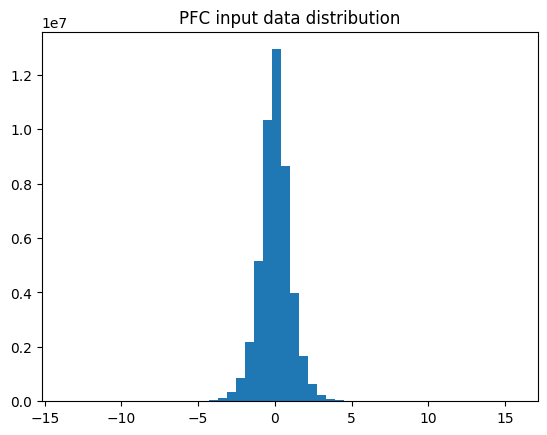

In [9]:
plt.hist(input_data.iloc[:, 4842+10:-11].values.flatten(), bins=50)
plt.title('PFC input data distribution')

Text(0.5, 1.0, 'PFC_from_HC output data distribution')

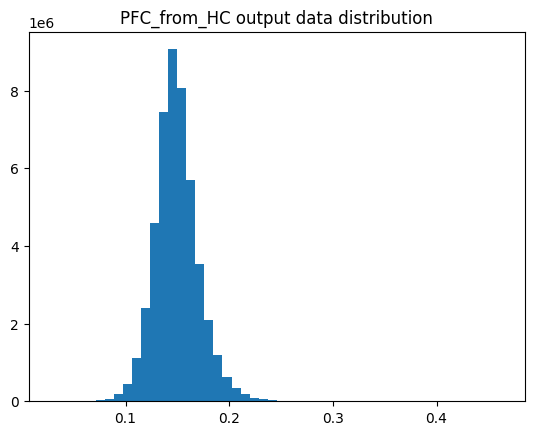

In [10]:
plt.hist(PFC_from_HC.iloc[:, :4850].values.flatten(), bins=50)
plt.title('PFC_from_HC output data distribution')

In [11]:
PFC_from_PFC = pd.read_csv(os.path.join(output_path, f'recon{dataset_abbrev[1]}_epoch{epoch}_vae{dataset_abbrev[1]}.csv'))
PFC_from_PFC

/tmp/ipykernel_777057/1032656946.py:1: DtypeWarning: Columns (4860) have mixed types. Specify dtype option on import or set low_memory=False.
  PFC_from_PFC = pd.read_csv(os.path.join(output_path, f'recon{dataset_abbrev[1]}_epoch{epoch}_vae{dataset_abbrev[1]}.csv'))


,0,1,2,3,4,5,6,7,8,9,...,barcode_PFC,subclass_PFC,cell_type_PFC,SCBID_PFC,MouseID_PFC,Age_PFC,Genotype_PFC,14-6-residual_PFC,14-6-Bin_PFC,strain
0,0.146338,0.135762,0.158540,0.188771,0.138338,0.139878,0.139852,0.186856,0.114429,0.201978,...,CK19032_AATCACGGTTCAGTAC-1,334 Microglia NN,Immune,CK19032,1596,14,5,0.738297,3,124
1,0.144756,0.131027,0.155679,0.185137,0.135898,0.153379,0.139209,0.187850,0.116974,0.184572,...,CK19032_TACGGTAGTACCGGAA-1,319 Astro-TE NN,Astrocytes,CK19032,1596,14,5,0.738297,3,124
2,0.164883,0.143286,0.159267,0.160674,0.123275,0.153036,0.128785,0.170294,0.141168,0.169019,...,CK19032_GCAGCCATCGAACACT-1,030 L6 CT CTX Glut,Glut,CK19032,1596,14,5,0.738297,3,124
3,0.153293,0.141494,0.146724,0.139443,0.160311,0.154344,0.132236,0.159964,0.141606,0.148314,...,CK19032_TTACCATAGCCACTCG-1,007 L2/3 IT CTX Glut,Glut,CK19032,1596,14,5,0.738297,3,124
4,0.148607,0.140850,0.163026,0.205395,0.116475,0.137364,0.141506,0.191639,0.122320,0.215053,...,CK19032_CTCATTAGTGTCCTAA-1,327 Oligo NN,Oligo,CK19032,1596,14,5,0.738297,3,124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,0.145176,0.134927,0.151353,0.190972,0.140887,0.150864,0.148940,0.189644,0.119361,0.199890,...,CK19090_TTTACGTAGTGATAGT-1,334 Microglia NN,Immune,CK19090,1490,14,5,-0.460462,1,28
9747,0.162387,0.144168,0.150654,0.140670,0.143220,0.176493,0.121282,0.161126,0.149765,0.136078,...,CK19090_CCGTTCAAGAATTTGG-1,066 NDB-SI-ant Prdm12 Gaba,Gaba,CK19090,1490,14,5,-0.460462,1,28
9748,0.151015,0.142444,0.159754,0.190817,0.100948,0.154273,0.138179,0.192914,0.120254,0.186813,...,CK19090_AATTCCTAGACTTGTC-1,327 Oligo NN,Oligo,CK19090,1490,14,5,-0.460462,1,28
9749,0.159558,0.151002,0.149440,0.141732,0.146461,0.165138,0.125357,0.160649,0.149173,0.142225,...,CK19090_CCGGTAGTCCTTCAGC-1,010 IT AON-TT-DP Glut,Glut,CK19090,1490,14,5,-0.460462,1,28


Text(0.5, 1.0, 'PFC_from_PFC output data distribution')

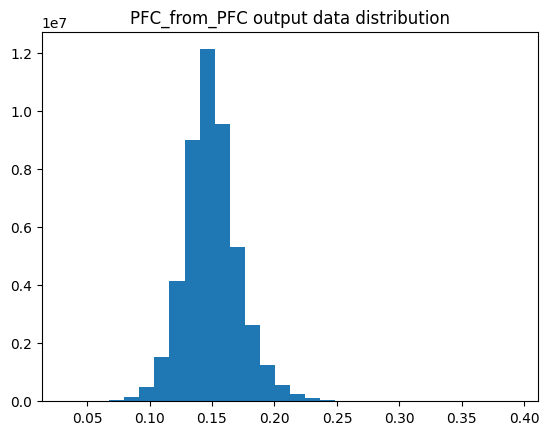

In [12]:
plt.hist(PFC_from_PFC.iloc[:, :4850].values.flatten(), bins=30)
plt.title('PFC_from_PFC output data distribution')

In [13]:
np.max(PFC_from_PFC.iloc[:, :4842]), np.min(PFC_from_PFC.iloc[:, :4842]), np.std(PFC_from_PFC.iloc[:, :4842]).mean(), np.mean(PFC_from_PFC.iloc[:, :4842])

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


(0.3926257, 0.031790584, 0.018679009408315805, 0.14959204457793224)

Text(0.5, 1.0, 'HC input data distribution')

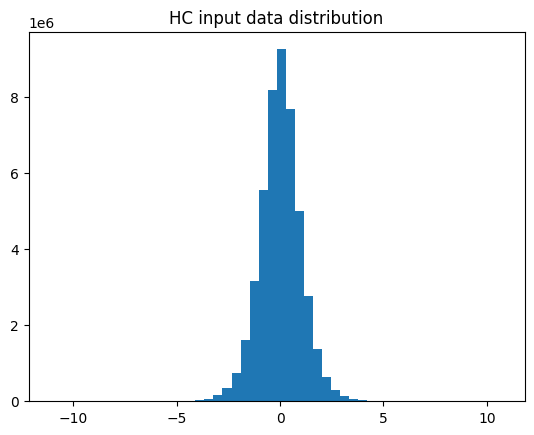

In [14]:
plt.hist(input_data.iloc[:, :4842].values.flatten(), bins=50)
plt.title('HC input data distribution')

In [15]:
HC_from_PFC = pd.read_csv(os.path.join(output_path, f'recon{dataset_abbrev[0]}_epoch{epoch}_vae{dataset_abbrev[1]}.csv'))

/tmp/ipykernel_777057/1136135108.py:1: DtypeWarning: Columns (4852) have mixed types. Specify dtype option on import or set low_memory=False.
  HC_from_PFC = pd.read_csv(os.path.join(output_path, f'recon{dataset_abbrev[0]}_epoch{epoch}_vae{dataset_abbrev[1]}.csv'))


Text(0.5, 1.0, 'HC from PFC data distribution')

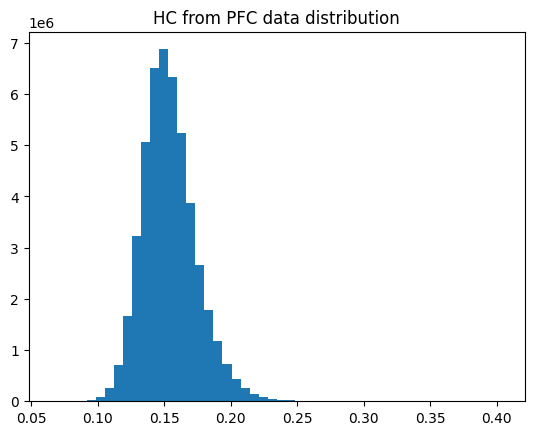

In [16]:
plt.hist(HC_from_PFC.iloc[:, :4842].values.flatten(), bins=50)
plt.title('HC from PFC data distribution')

In [17]:
HC_from_HC = pd.read_csv(os.path.join(output_path, f'recon{dataset_abbrev[0]}_epoch{epoch}_vae{dataset_abbrev[0]}.csv'))

/tmp/ipykernel_777057/3228135352.py:1: DtypeWarning: Columns (4852) have mixed types. Specify dtype option on import or set low_memory=False.
  HC_from_HC = pd.read_csv(os.path.join(output_path, f'recon{dataset_abbrev[0]}_epoch{epoch}_vae{dataset_abbrev[0]}.csv'))


Text(0.5, 1.0, 'HC from PFC data distribution')

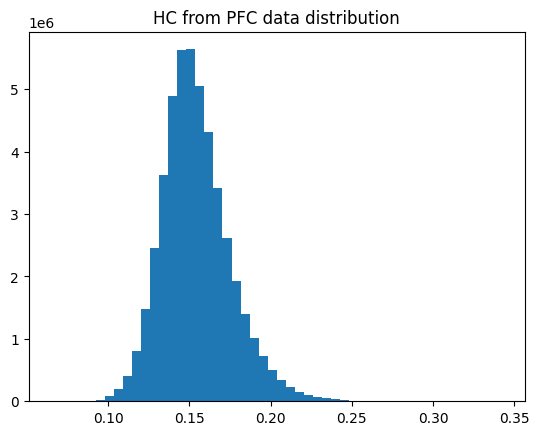

In [18]:
plt.hist(HC_from_HC.iloc[:, :4842].values.flatten(), bins=50)
plt.title('HC from PFC data distribution')

In [19]:
def standardizer(input_array):
    mean = np.mean(input_array)
    std = np.std(input_array)
    return (input_array - mean)/std

In [20]:
input_data['CFM_14_5_snRNA_PFC'].unique()

array([59.16, 29.38, 28.04, 41.56, 31.38, 52.09, 24.44, 56.67, 49.96,
       53.16, 20.58, 39.47])

In [21]:
original_cfm = standardizer(input_data['CFM_14_5_snRNA_PFC'].values)

Text(0.5, 1.0, 'Original cfm distribution')

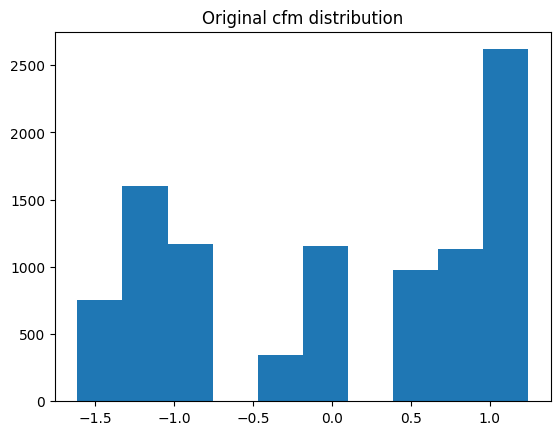

In [22]:
plt.hist(original_cfm, bins=10)
plt.title('Original cfm distribution')

In [23]:
PFC_from_HC.iloc[:, :4852]

,0,1,2,3,4,5,6,7,8,9,...,4842,4843,4844,4845,4846,4847,4848,4849,4850,barcode_PFC
0,0.154988,0.137181,0.158549,0.171073,0.138296,0.153876,0.131109,0.176736,0.135001,0.169701,...,0.136851,0.169414,0.165041,0.110163,0.143207,0.141276,0.150711,0.165875,0.492517,CK19032_AATCACGGTTCAGTAC-1
1,0.142954,0.137834,0.147395,0.177874,0.168916,0.143474,0.171384,0.178672,0.116269,0.201101,...,0.157433,0.183663,0.180322,0.121406,0.121233,0.142380,0.147325,0.190977,0.225393,CK19032_TACGGTAGTACCGGAA-1
2,0.142624,0.138211,0.156813,0.200436,0.134399,0.152918,0.140766,0.192248,0.119879,0.198828,...,0.145860,0.160616,0.174791,0.108495,0.119770,0.147872,0.148401,0.199024,0.335157,CK19032_GCAGCCATCGAACACT-1
3,0.154180,0.139734,0.160671,0.178323,0.128152,0.148499,0.134061,0.179878,0.131140,0.185116,...,0.141140,0.165098,0.166098,0.112606,0.134278,0.143218,0.150453,0.174528,0.423430,CK19032_TTACCATAGCCACTCG-1
4,0.143819,0.138792,0.161249,0.198736,0.132754,0.149307,0.135814,0.188174,0.123413,0.193918,...,0.144421,0.158501,0.165388,0.104285,0.121635,0.146009,0.150649,0.193177,0.446313,CK19032_CTCATTAGTGTCCTAA-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,0.144201,0.147265,0.124031,0.147442,0.164171,0.164291,0.155157,0.172092,0.131533,0.144601,...,0.136009,0.218192,0.218086,0.115303,0.146271,0.145627,0.144660,0.177509,0.323606,CK19090_TTTACGTAGTGATAGT-1
9747,0.152316,0.144705,0.133316,0.154922,0.152729,0.154626,0.139337,0.170555,0.134888,0.149135,...,0.136060,0.190349,0.199747,0.114594,0.145549,0.142308,0.145199,0.167706,0.454859,CK19090_CCGTTCAAGAATTTGG-1
9748,0.141034,0.148662,0.143984,0.172696,0.149716,0.161229,0.162360,0.177966,0.111968,0.177441,...,0.147774,0.193911,0.241250,0.118631,0.115634,0.149406,0.159507,0.209225,0.373447,CK19090_AATTCCTAGACTTGTC-1
9749,0.167668,0.141663,0.147883,0.142990,0.150254,0.167386,0.120533,0.162965,0.144247,0.141381,...,0.135385,0.181003,0.158688,0.121234,0.154323,0.140254,0.148482,0.137777,0.704718,CK19090_CCGGTAGTCCTTCAGC-1


Text(0.5, 1.0, 'PFC_from_HC predicted cfm distribution')

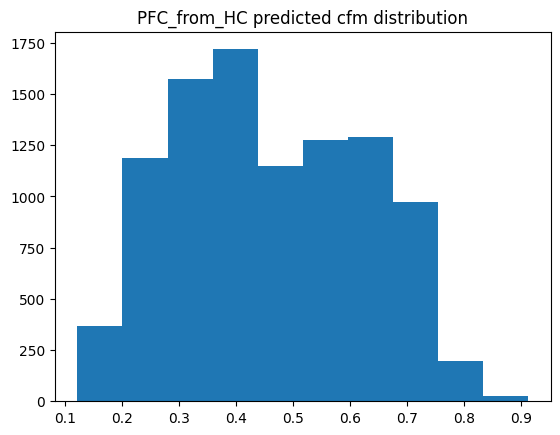

In [24]:
plt.hist(PFC_from_HC.iloc[:, 4850], bins=10)
plt.title('PFC_from_HC predicted cfm distribution')

Text(0.5, 1.0, 'PFC_from_HC predicted cfm distribution')

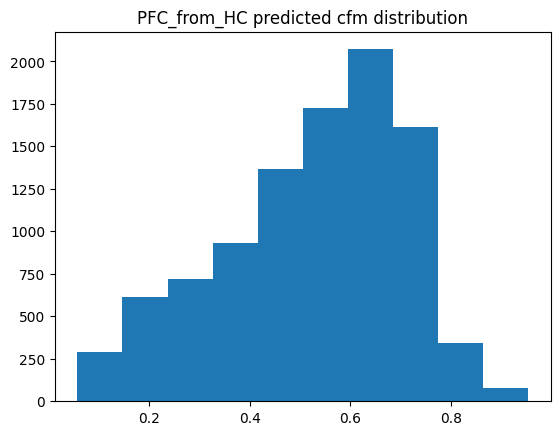

In [25]:
plt.hist(PFC_from_PFC.iloc[:, 4850], bins=10)
plt.title('PFC_from_HC predicted cfm distribution')

Text(0.5, 1.0, 'PFC_from_HC predicted cfm distribution')

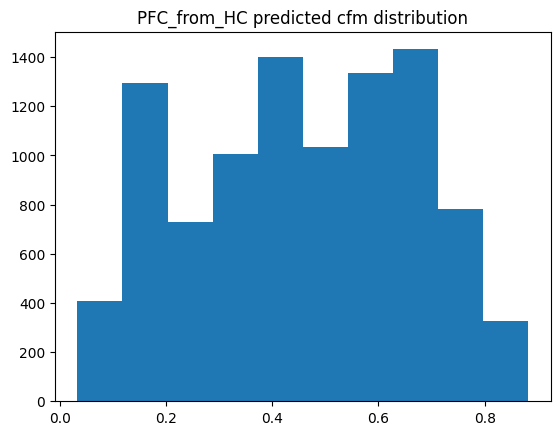

In [26]:
plt.hist(HC_from_HC.iloc[:, 4842], bins=10)
plt.title('PFC_from_HC predicted cfm distribution')

Text(0.5, 1.0, 'PFC_from_HC predicted cfm distribution')

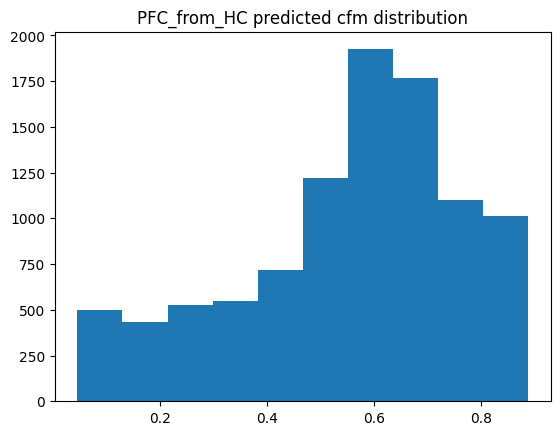

In [27]:
plt.hist(HC_from_PFC.iloc[:, 4842], bins=10)
plt.title('PFC_from_HC predicted cfm distribution')

In [28]:
exit()

For DO dataset

In [ ]:
input_data = pd.read_csv('/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio_cfc.csv')
input_data

,MouseID,0,1,2,3,4,5,6,7,8,...,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num,Diet,Mouse.ID,CFC.24mo.Average,cfc_bin
0,DO-1D-3001,11.181311,12.383703,13.223754,18.683861,-3.105873,15.071812,4.566722,-8.317668,15.178740,...,-0.282162,-0.284390,-0.302189,-0.302202,-0.302199,4,1D,DO-1D-3001,0.84,0
1,DO-1D-3003,14.611459,-0.662600,-24.308638,-22.627848,-18.261186,1.859805,6.543754,22.646550,-1.809972,...,-0.284586,-0.287381,-0.302189,-0.302203,-0.302198,4,1D,DO-1D-3003,83.69,8
2,DO-1D-3010,1.859422,-7.514837,1.146809,-10.576791,-14.123598,0.187016,2.846669,-21.453514,-14.552152,...,-0.283942,-0.284049,-0.302189,-0.302203,-0.302205,4,1D,DO-1D-3010,36.71,3
3,DO-1D-3011,6.336620,-19.787761,9.017313,-4.479619,12.846408,-5.231286,16.983432,-16.252265,-12.688484,...,-0.281745,-0.281171,-0.302189,-0.302205,-0.302193,4,1D,DO-1D-3011,21.96,2
4,DO-1D-3013,-23.926661,-7.046359,8.830735,1.312327,-0.527705,6.687224,-9.731708,6.568401,6.597907,...,-0.283412,-0.294808,-0.302189,-0.302202,-0.302156,4,1D,DO-1D-3013,6.93,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,DO-AL-0186,-5.162836,8.648018,-1.372207,10.970472,-1.921667,-3.733688,8.676810,-16.461100,-8.221440,...,-0.281315,-0.294808,-0.302211,-0.302210,-0.302156,5,AL,DO-AL-0186,20.44,2
497,DO-AL-0188,11.180352,-8.517944,8.474807,-6.834697,12.355449,20.439765,11.830693,-11.656498,-24.270286,...,-0.280596,-0.283513,-0.302216,-0.302200,-0.302202,5,AL,DO-AL-0188,18.31,1
498,DO-AL-0191,3.404846,0.426192,-2.073981,-12.920995,-19.462683,6.055004,9.646308,4.292594,10.025039,...,-0.282754,-0.294808,-0.302207,-0.302194,-0.302156,5,AL,DO-AL-0191,24.71,2
499,DO-1D-3083,-20.852529,7.764088,-5.252014,8.705888,-11.405415,13.622378,1.249871,8.666080,14.656721,...,-0.274878,-0.277799,-0.302223,-0.302210,-0.302199,4,1D,DO-1D-3083,31.07,3


: 

(-80.0, 80.0)

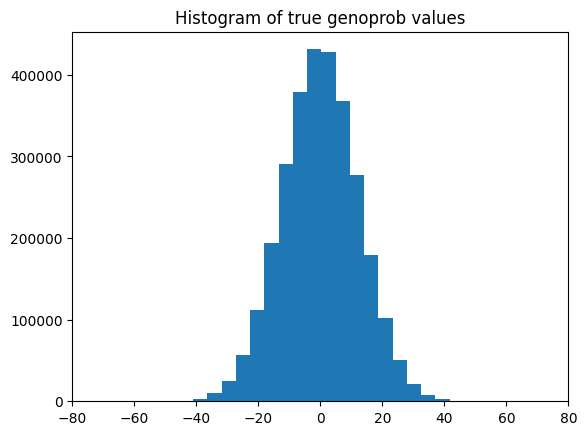

In [ ]:
plt.hist(input_data.iloc[:, 1:5874].values.flatten(), bins=30)
plt.title('Histogram of true genoprob values')
plt.xlim(-80,80)

In [ ]:
geno_from_geno = pd.read_csv('/home/rachel/Desktop/mm-vae results/caloric_restriction_DO_mice/vanillavae4_genoreweighted_test/reconGeno_epoch500_vaeGeno.csv')
geno_from_geno

,0,1,2,3,4,5,6,7,8,9,...,5865,5866,5867,5868,5869,5870,5871,5872,Diet,MouseID
0,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,1D,DO-1D-3001
1,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,1D,DO-1D-3003
2,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,1D,DO-1D-3010
3,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,1D,DO-1D-3011
4,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,1D,DO-1D-3013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,AL,DO-AL-0186
497,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,AL,DO-AL-0188
498,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,AL,DO-AL-0191
499,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,1D,DO-1D-3083


(-5.0, 5.0)

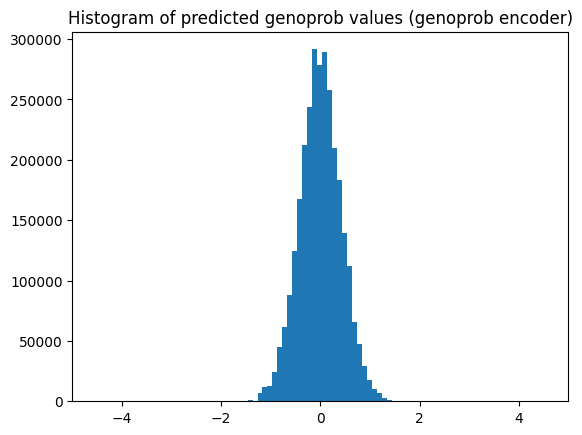

In [ ]:
plt.hist(geno_from_geno.iloc[:, :-2].values.flatten(), bins=30)
plt.title('Histogram of predicted genoprob values (genoprob encoder)')
plt.xlim(-5, 5)

In [ ]:
geno_from_physio = pd.read_csv('/home/rachel/Desktop/mm-vae results/caloric_restriction_DO_mice/vanillavae4_genoreweighted_test/reconGeno_epoch500_vaePhysio.csv')
geno_from_physio

,0,1,2,3,4,5,6,7,8,9,...,5865,5866,5867,5868,5869,5870,5871,5872,Diet,MouseID
0,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,1D,DO-1D-3001
1,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,1D,DO-1D-3003
2,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,1D,DO-1D-3010
3,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,1D,DO-1D-3011
4,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,1D,DO-1D-3013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,AL,DO-AL-0186
497,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,AL,DO-AL-0188
498,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,AL,DO-AL-0191
499,0.123065,-0.361141,0.018128,-0.570753,0.172021,0.40401,-0.034183,-0.730188,-0.273018,0.668633,...,-0.19516,0.245913,-0.400001,0.126425,-0.558715,0.322749,0.501822,0.214441,1D,DO-1D-3083


(-5.0, 5.0)

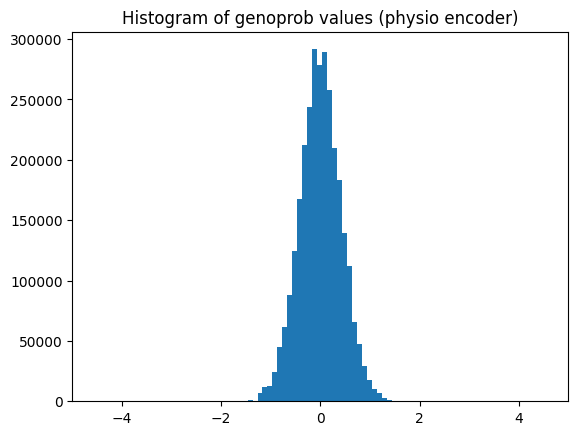

In [ ]:
plt.hist(geno_from_physio.iloc[:, :-2].values.flatten(), bins=30)
plt.title('Histogram of genoprob values (physio encoder)')
plt.xlim(-5, 5)

Text(0.5, 1.0, 'Histogram of true physio data values')

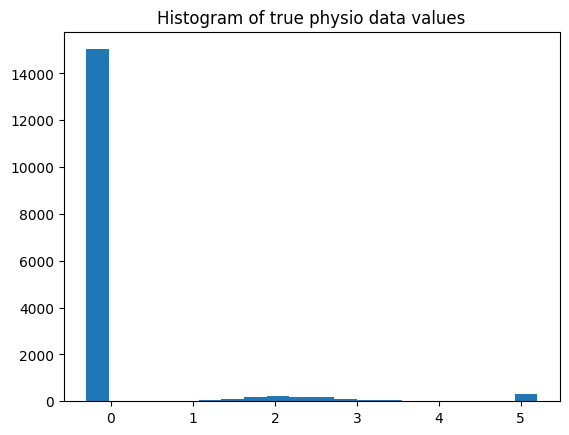

In [ ]:
plt.hist(input_data.iloc[:, 5876:-5].values.flatten(), bins=20)
plt.title('Histogram of true physio data values')

In [ ]:
physio_from_physio = pd.read_csv('/home/rachel/Desktop/mm-vae results/caloric_restriction_DO_mice/vanillavae3_test/reconPhysio_epoch150_vaePhysio.csv')

In [ ]:
physio_from_physio

,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,Diet,MouseID
0,25.123844,1005.9017,-0.298832,-0.298156,-0.297683,-0.282345,-0.285852,-0.282915,-0.23804,-0.238582,...,-0.302549,-0.278471,-0.280741,-0.286508,-0.302326,-0.302315,-0.302102,2.860951,1D,DO-1D-3001
1,25.123844,1005.9017,-0.298832,-0.298156,-0.297683,-0.282345,-0.285852,-0.282915,-0.23804,-0.238582,...,-0.302549,-0.278471,-0.280741,-0.286508,-0.302326,-0.302315,-0.302102,2.860951,1D,DO-1D-3003
2,25.123844,1005.9017,-0.298832,-0.298156,-0.297683,-0.282345,-0.285852,-0.282915,-0.23804,-0.238582,...,-0.302549,-0.278471,-0.280741,-0.286508,-0.302326,-0.302315,-0.302102,2.860951,1D,DO-1D-3010
3,25.123844,1005.9017,-0.298832,-0.298156,-0.297683,-0.282345,-0.285852,-0.282915,-0.23804,-0.238582,...,-0.302549,-0.278471,-0.280741,-0.286508,-0.302326,-0.302315,-0.302102,2.860951,1D,DO-1D-3011
4,25.123844,1005.9017,-0.298832,-0.298156,-0.297683,-0.282345,-0.285852,-0.282915,-0.23804,-0.238582,...,-0.302549,-0.278471,-0.280741,-0.286508,-0.302326,-0.302315,-0.302102,2.860951,1D,DO-1D-3013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,25.123844,1005.9017,-0.298832,-0.298156,-0.297683,-0.282345,-0.285852,-0.282915,-0.23804,-0.238582,...,-0.302549,-0.278471,-0.280741,-0.286508,-0.302326,-0.302315,-0.302102,2.860951,AL,DO-AL-0186
497,25.123844,1005.9017,-0.298832,-0.298156,-0.297683,-0.282345,-0.285852,-0.282915,-0.23804,-0.238582,...,-0.302549,-0.278471,-0.280741,-0.286508,-0.302326,-0.302315,-0.302102,2.860951,AL,DO-AL-0188
498,25.123844,1005.9017,-0.298832,-0.298156,-0.297683,-0.282345,-0.285852,-0.282915,-0.23804,-0.238582,...,-0.302549,-0.278471,-0.280741,-0.286508,-0.302326,-0.302315,-0.302102,2.860951,AL,DO-AL-0191
499,25.123844,1005.9017,-0.298832,-0.298156,-0.297683,-0.282345,-0.285852,-0.282915,-0.23804,-0.238582,...,-0.302549,-0.278471,-0.280741,-0.286508,-0.302326,-0.302315,-0.302102,2.860951,1D,DO-1D-3083


(-5.0, 5.0)

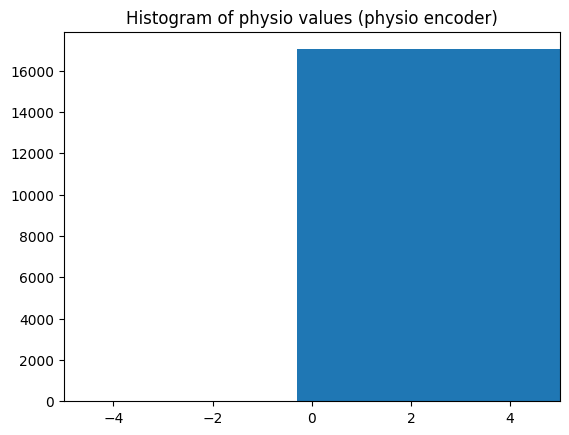

In [ ]:
plt.hist(physio_from_physio.iloc[:, :-2].values.flatten(), bins=100)
plt.title('Histogram of physio values (physio encoder)')
plt.xlim(-5, 5)